# 3D Computer Vision Laboratory — Discovering Stereo Depth (Skeleton)

Today's goal: starting from a pair of stereo photographs, work out how to estimate how far away every point in the scene is.

You are given:
- code to download and load a rectified stereo image pair,
- code that turns a disparity map into a depth map and a 3D visualization.

You are **not** given: a way to compute the disparity map itself. That is today's task, split into two functions for you to design and implement — `compute_block_score` and `compute_disparity_loop` — guided by discussion questions and pseudocode.

> **Rectification reminder.** The two images you'll work with have been *rectified*: for every 3D point, its projections in the left and right image fall on the **same row**. Keep this in mind — it should shape how you search for correspondences.

## 1. Dataset

We use the **Art** scene from the [Middlebury 2005 stereo dataset](https://vision.middlebury.edu/stereo/data/scenes2005/), a standard benchmark for stereo algorithms. The archive contains the rectified left/right image pair (`view1.png`, `view5.png`).

In [3]:
# If running outside Colab and any package is missing, uncomment:
# !pip install opencv-python numpy matplotlib numba plotly

import os
import urllib.request
import zipfile

DATA_URL = "https://vision.middlebury.edu/stereo/data/scenes2005/FullSize/zip-2views/Art-2views.zip"
ZIP_PATH = "Art-2views.zip"
DATA_DIR = "Art"

if not os.path.isdir(DATA_DIR):
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(".")
    print("Done.")
else:
    print("Dataset already present, skipping download.")


Dataset already present, skipping download.


## 2. Imports

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from numba import njit  # optional: you can use this later to speed up your functions


## 3. Loading the stereo pair

Load both views, convert them to grayscale, and look at them side by side.

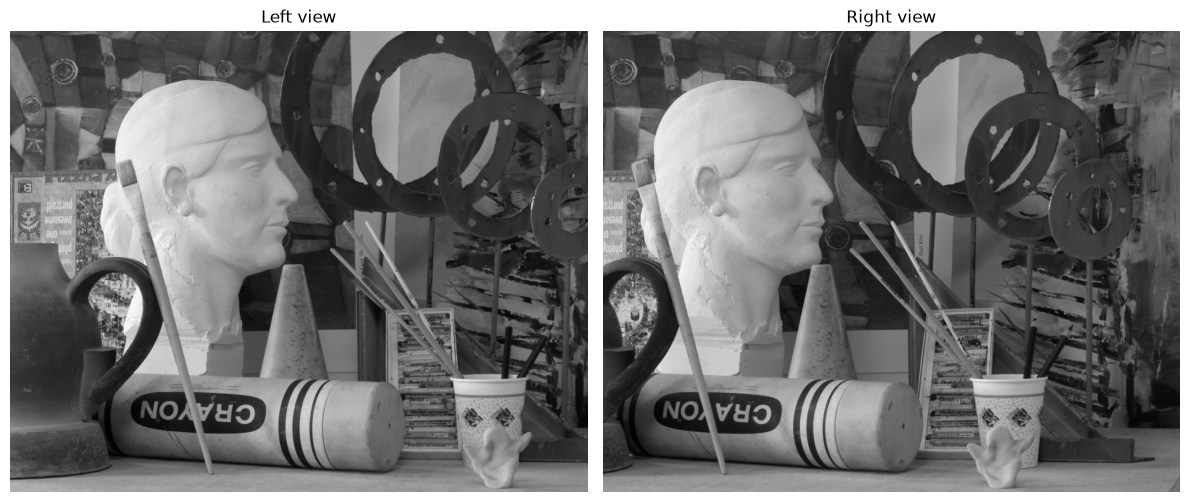

In [5]:
img_left_color = cv2.imread("Art/view1.png")
img_right_color = cv2.imread("Art/view5.png")

img_left = cv2.cvtColor(img_left_color, cv2.COLOR_BGR2GRAY)
img_right = cv2.cvtColor(img_right_color, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_left, cmap="gray");  axes[0].set_title("Left view");  axes[0].axis("off")
axes[1].imshow(img_right, cmap="gray"); axes[1].set_title("Right view"); axes[1].axis("off")
plt.tight_layout()
plt.show()


**Look closely at the two images.** Some objects appear at a different horizontal position in the left vs. right image.

- Do all objects shift by the same amount?
- What might that shift tell you about how far away an object is?

### Work at a small resolution while developing

Your first implementation will run in plain Python, with no acceleration — looping over every pixel of a full-resolution image would take far too long while you're testing and debugging. Keep `DOWNSCALE` small (e.g. `0.2`–`0.3`) for now. Once your functions work correctly, see "Going further" at the end of this notebook for how to scale up.

In [6]:
DOWNSCALE = 0.25  # keep this small while developing; see note above

if DOWNSCALE != 1.0:
    new_size = (int(img_left.shape[1] * DOWNSCALE), int(img_left.shape[0] * DOWNSCALE))
    img_left = cv2.resize(img_left, new_size, interpolation=cv2.INTER_AREA)
    img_right = cv2.resize(img_right, new_size, interpolation=cv2.INTER_AREA)
    img_left_color = cv2.resize(img_left_color, new_size, interpolation=cv2.INTER_AREA)

print("Working resolution:", img_left.shape)


Working resolution: (277, 347)


## 4. Task 1 — How similar are two image patches?

The core idea behind block matching: to find where a point from the left image reappears in the right image, compare small patches ("blocks") of pixels around candidate points and measure how similar they are.

**Discuss with your group:**
- Given two same-sized grayscale patches, what is a simple way to turn "how similar are they" into a single number?
- Can you think of more than one reasonable way to do this? What might be the trade-offs?
- Should two identical patches score `0`? Should a *larger* score mean *more* similar, or *less* similar? (Either convention works — just be consistent.)

Implement your idea in `compute_block_score` below. (This is also called a "closeness" or "cost" function.)

In [ ]:
def compute_block_score(left_block, right_block):
    """
    TODO (Task 1): return a single number describing how "close" / similar
    two equally-sized image patches are.

    Pseudocode:
        1. 'left_block' and 'right_block' are 2D numpy arrays of the same shape.
        2. Compute some per-pixel comparison between the two blocks.
        3. Combine all the per-pixel values into ONE score for the whole block.
        4. Decide (and remember!) whether a SMALLER or LARGER score means
           "more similar" -- you will need the same convention in Task 2.

    Discuss with your group before coding -- see the markdown cell above.
    """
    mino = 
    res = np.zeros((len(left_block),len(left_block)))
    
    raise NotImplementedError("Implement compute_block_score")


## 5. Task 2 — Searching for the best match along the row

Now use your scoring function to find, for each pixel in the left image, the best-matching pixel in the right image.

**Discuss with your group:**
- Because the images are rectified, you already know *which row* to search in the right image. Which *columns* are worth checking?
- This dataset's cameras are arranged the standard way (left camera physically to the left of the right camera). Based on that, in which direction — and by how much, at most — would you expect a point to shift between the left and right image?
- Why limit the search to some maximum disparity `max_disparity`, instead of scanning the entire row?
- What should happen for pixels near the border of the image, where a full block doesn't fit?

Implement your plan in `compute_disparity_loop` below (see the pseudocode inside for scaffolding).

In [ ]:
def compute_disparity_loop(img_left, img_right, kernel_size, max_disparity):
    """
    TODO (Task 2): for every pixel of the left image, find the disparity 'd'
    that makes its neighborhood look most like a neighborhood in the right
    image, and store it in a disparity map.

    Pseudocode:
        create disparity_map, same height/width as img_left, filled with 0
        offset = kernel_size // 2   # how far a block extends from its center

        for every (row, col) in img_left, staying 'offset' pixels away from
        every border (so a full block always fits):

            left_block = the kernel_size x kernel_size patch of img_left
                         centered on (row, col)

            best_score = ...   # what should this start as, given your
                                # convention from Task 1?
            best_d = 0

            for every candidate disparity d from 0 up to max_disparity:
                # Where should the matching block be in img_right, given the
                # rectification reminder and the camera arrangement?
                target_col = col ??? d

                if the block around (row, target_col) would fall outside
                the image: stop trying larger d for this pixel

                right_block = the kernel_size x kernel_size patch of
                              img_right centered on (row, target_col)

                score = compute_block_score(left_block, right_block)

                if score is BETTER than best_score:
                    best_score, best_d = score, d

            disparity_map[row, col] = best_d

        return disparity_map
    """
    raise NotImplementedError("Implement compute_disparity_loop")


In [ ]:
def compute_disparity_map(img_left, img_right, kernel_size=7, max_disparity=25):
    """
    Computes a disparity map for a rectified grayscale stereo pair.
    """
    return compute_disparity_loop(img_left, img_right, kernel_size, max_disparity)


## 6. Running your implementation

Once both functions above are implemented, run the following cell. Start with small `kernel_size` / `max_disparity` values and a low `DOWNSCALE` (above) to sanity-check correctness before scaling up — a full run can be slow without acceleration (see "Going further").

In [ ]:
try:
    disp = compute_disparity_map(img_left, img_right, kernel_size=7, max_disparity=50)

    # Optional post-processing: median blur removes isolated mismatches ("salt & pepper" noise)
    disp_filtered = cv2.medianBlur(disp, 5)

    plt.figure(figsize=(8, 6))
    plt.imshow(disp_filtered, cmap="jet")
    plt.colorbar(label="Disparity (pixels)")
    plt.title("Disparity map")
    plt.axis("off")
    plt.show()
except NotImplementedError as e:
    print(f"Not implemented yet ({e}) -- skipping your estimate for now.")
    print("The ground-truth section below stands in for it so the rest of the notebook still runs;")
    print("implement compute_block_score and compute_disparity_loop above, then re-run this cell.")
    disp_filtered = None


Not implemented yet (Implement compute_disparity_loop) -- skipping your estimate for now.
The ground-truth section below stands in for it so the rest of the notebook still runs;
implement compute_block_score and compute_disparity_loop above, then re-run this cell.


### Sanity check: comparing against the ground truth

Once your disparity map runs, it's hard to tell from the picture alone whether it's actually *correct* (beyond obvious noise in occluded/textureless regions). The Middlebury dataset ships a ground-truth disparity map (`disp1.png`) for the left view, so you can compare your estimate against the true answer.

Pixel values in `disp1.png` are not the disparity directly: since true disparities in this scene are large, Middlebury stores `disparity - DMIN` (a plain 8-bit PNG can't hold values above 255) and reserves `0` for "unknown". `DMIN` for this scene is given in `Art/dmin.txt`. We add it back, then rescale by `DOWNSCALE` — exactly like the focal length below — since disparity shrinks/grows proportionally with image size.

If your estimated disparities look nothing like the ground truth's range (e.g. your estimate is pinned near `max_disparity`), that's a sign `max_disparity` is too small to cover this scene's true disparities.

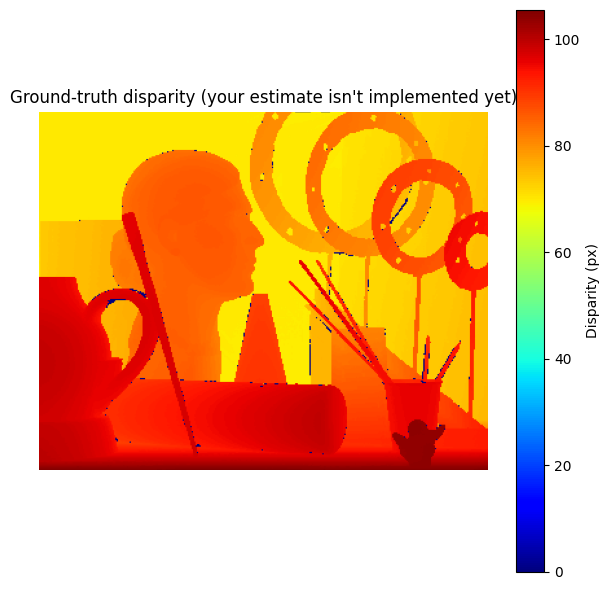

In [ ]:
DMIN = 200  # from Art/dmin.txt

def load_ground_truth_disparity(path, dmin, scale=1.0):
    """
    Loads a Middlebury ground-truth disparity map, decoded to true disparity
    (in pixels) at the given working resolution. Pixel value 0 = unknown.
    """
    gt_raw = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    valid = gt_raw > 0
    gt_disp = np.zeros_like(gt_raw, dtype=np.float32)
    gt_disp[valid] = gt_raw[valid].astype(np.float32) + dmin

    if scale != 1.0:
        new_size = (int(gt_disp.shape[1] * scale), int(gt_disp.shape[0] * scale))
        gt_disp = cv2.resize(gt_disp, new_size, interpolation=cv2.INTER_NEAREST) * scale

    return gt_disp

disp_gt = load_ground_truth_disparity("Art/disp1.png", dmin=DMIN, scale=DOWNSCALE)

if disp_filtered is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    im0 = axes[0].imshow(disp_filtered, cmap="jet"); axes[0].set_title("Estimated disparity"); axes[0].axis("off")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, label="Disparity (px)")
    im1 = axes[1].imshow(disp_gt, cmap="jet"); axes[1].set_title("Ground-truth disparity"); axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, label="Disparity (px)")
else:
    plt.figure(figsize=(6, 6))
    plt.imshow(disp_gt, cmap="jet")
    plt.colorbar(label="Disparity (px)")
    plt.title("Ground-truth disparity (your estimate isn't implemented yet)")
    plt.axis("off")
plt.tight_layout()
plt.show()

# --- Pick which disparity map feeds the depth map and 3D view below ---
if disp_filtered is None:
    disp_filtered = disp_gt   # fall back to ground truth until your implementation is ready
else:
    disp_filtered = disp_filtered   # use your estimated disparity (default)
    # disp_filtered = disp_gt       # uncomment to use the ground truth instead


## 7. From disparity to depth

For a rectified pinhole stereo pair with focal length $f$ (in pixels) and baseline $B$ (distance between camera centers), similar triangles give:

$$
Z = \frac{f \cdot B}{d}
$$

Larger disparity means closer to the camera; $d = 0$ is undefined (a point at infinity) and is treated as invalid.

For the Middlebury *Art* scene (full-size calibration): $f = 3740$ px, $B = 160$ mm. Because we downscaled the images, we rescale $f$ by `DOWNSCALE` to match the working resolution.

In [ ]:
FOCAL_LENGTH_PX = 3740.0  # at full resolution
BASELINE_MM = 160.0

def disparity_to_depth(disp_map, focal_length=FOCAL_LENGTH_PX, baseline=BASELINE_MM):
    """
    Converts a disparity map (pixels) to a depth map (millimeters): Z = f * B / d
    """
    disp_f = disp_map.astype(np.float32)
    with np.errstate(divide="ignore", invalid="ignore"):
        depth_map = (focal_length * baseline) / disp_f
    depth_map[disp_f == 0] = 0.0  # undefined depth
    return depth_map

effective_focal_length = FOCAL_LENGTH_PX * DOWNSCALE
depth_map = disparity_to_depth(disp_filtered, focal_length=effective_focal_length)


## 8. 3D visualization

We project each pixel to $(x, y, Z)$ using its image coordinates and estimated depth, and color it with the original image color, giving a rough 3D point cloud of the scene.

In [ ]:
import plotly.graph_objects as go

def plot_depth_map_3d(depth_map, img_color_bgr, step=4, max_depth_percentile=85):
    """
    Renders a depth map as a colored 3D point cloud.

    Near-zero disparities map to very large Z (Z = f*B/d), so a small number of
    far-away/noisy points can dominate the z-range and flatten the rest of the
    cloud. Points beyond `max_depth_percentile` of the valid depth distribution
    are dropped before plotting; set it to None to disable filtering.
    """
    depth_ds = depth_map[::step, ::step]
    img_ds = cv2.cvtColor(img_color_bgr, cv2.COLOR_BGR2RGB)[::step, ::step, :]

    h, w = depth_ds.shape
    xs, ys = np.meshgrid(np.arange(w), np.arange(h))
    xs, ys, zs = xs.flatten(), ys.flatten(), depth_ds.flatten()
    colors = img_ds.reshape(-1, 3)

    valid = zs > 0
    if max_depth_percentile is not None:
        max_depth = np.percentile(zs[valid], max_depth_percentile)
        valid &= zs <= max_depth
    xs, ys, zs, colors = xs[valid], ys[valid], zs[valid], colors[valid]
    color_strings = [f"rgb({r},{g},{b})" for r, g, b in colors]

    fig = go.Figure(data=[go.Scatter3d(
        x=xs, y=ys, z=zs, mode="markers",
        marker=dict(size=2, color=color_strings, opacity=0.8),
    )])
    fig.update_layout(
        title="3D reconstruction from stereo disparity",
        scene=dict(xaxis_title="x (px)", yaxis_title="y (px)", zaxis_title="depth Z (mm)"),
    )
    fig.show()

plot_depth_map_3d(depth_map, img_left_color, step=4)


## 9. Going further (optional, once your functions work)

- **Speed up with Numba:** decorate `compute_block_score` and `compute_disparity_loop` with `@njit` (imported above from `numba`). Numba only supports a subset of Python/NumPy, so keep the code simple (basic loops, NumPy arrays, no Python objects). This lets you push `DOWNSCALE` much closer to `1.0`.
- **Try a different closeness function**, e.g. Sum of Squared Differences instead of Sum of Absolute Differences, and compare the resulting disparity maps.
- **Vary the parameters:** what happens to the disparity map as you change `kernel_size`? `max_disparity`?
- **Find the weak spots:** where does your disparity map look worst (noisiest / clearly wrong)? Can you relate that to properties of the image in those regions (e.g. flat color, repeating pattern, only visible in one view)?